- AI4AIS
    * Description: AI4AIS data cube for the Larsen C ice shelf cube. In addition to wind speed, surface mass balance, and ice velocity, we incorporate surface elevation, surface melt, supraglacial lakes, and other currently available datasets. In later stages we will include novel datasets for ice shelf damage and strain rate developed as part of the project. A GRF representation of each monthly timestep for each dataset is generated. Using the R-INLA package values for an GRF fitting each input dataset are estimated at the vertices of a mesh covering the study area. These values are regressed to a uniform grid to create a datacube analogous to a pixel image.
    * Original Data Source: X
    * Reference: X
    * OSC entry: https://opensciencedata.esa.int/products/ai4ais-larsen-c-ice-shelf-cube/collection
    * License: CC-BY-NC-4.0
    * Repo Folder: ./datasets/ai4ais/


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


url = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ai4ais/output_store.zarr/'

ds = xr.open_zarr(url, chunks={"time": 6}, decode_times=False)
ds

<xarray.Dataset> Size: 49GB
Dimensions:                       (easting: 1551, northing: 1651, time: 108)
Coordinates:
  * easting                       (easting) float64 12kB -2.35e+06 ... -2.04e+06
  * northing                      (northing) float64 13kB 9.7e+05 ... 1.3e+06
  * time                          (time) float64 864B 0.0 1.0 ... 106.0 107.0
Data variables: (12/22)
    basal_melt                    (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    basal_melt_uncertainty        (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    damage                        (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    damage_coherence              (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    damage_coherence_uncertainty  (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    damage_uncertainty            (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    ...                            ...
    RACMO_smb                     (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    RACMO_smb_uncertainty         (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    windspeed_u                   (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    windspeed_u_uncertainty       (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    windspeed_v                   (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>
    windspeed_v_uncertainty       (easting, northing, time) float64 2GB dask.array<chunksize=(1551, 1651, 6), meta=np.ndarray>

In [2]:
# assign readble monthly dates
ds = ds.assign_coords(
    date=("time", pd.date_range("2014-01-01", periods=ds.sizes["time"], freq="MS"))
).swap_dims({"time": "date"})

# select variables
firn_thickness_mean = ds.firn_thickness.mean("date")
basal_melt_mean = ds.basal_melt.mean("date")
lake_persistence = (ds.lakes > 0).mean("date")

speed_u = ds.ice_velocity_u.mean("date")
speed_v = ds.ice_velocity_v.mean("date")
speed = np.hypot(speed_u, speed_v)

In [ ]:
# assert values are different
np.isclose(ds.firn_thickness.isel(date=-1).values, ds.firn_thickness.isel(date=6).values, equal_nan=True).all()

np.False_

In [4]:
# sample with a 20 step for faster plotting
# increase the step for faster loading
step = 20
x = ds.easting[::step] / 1000
y = ds.northing[::step] / 1000

firn_thickness_plot = firn_thickness_mean[::step, ::step].compute()
melt_plot = basal_melt_mean[::step, ::step].compute()
lake_plot = lake_persistence[::step, ::step].compute()

u_plot = speed_u[::step, ::step].compute()
v_plot = speed_v[::step, ::step].compute()


In [5]:
# approx speed, for efficent plotting and scaling
qstep = 6
speed_plot = np.hypot(u_plot.values, v_plot.values)
qscale = np.nanpercentile(speed_plot, 95) * 35

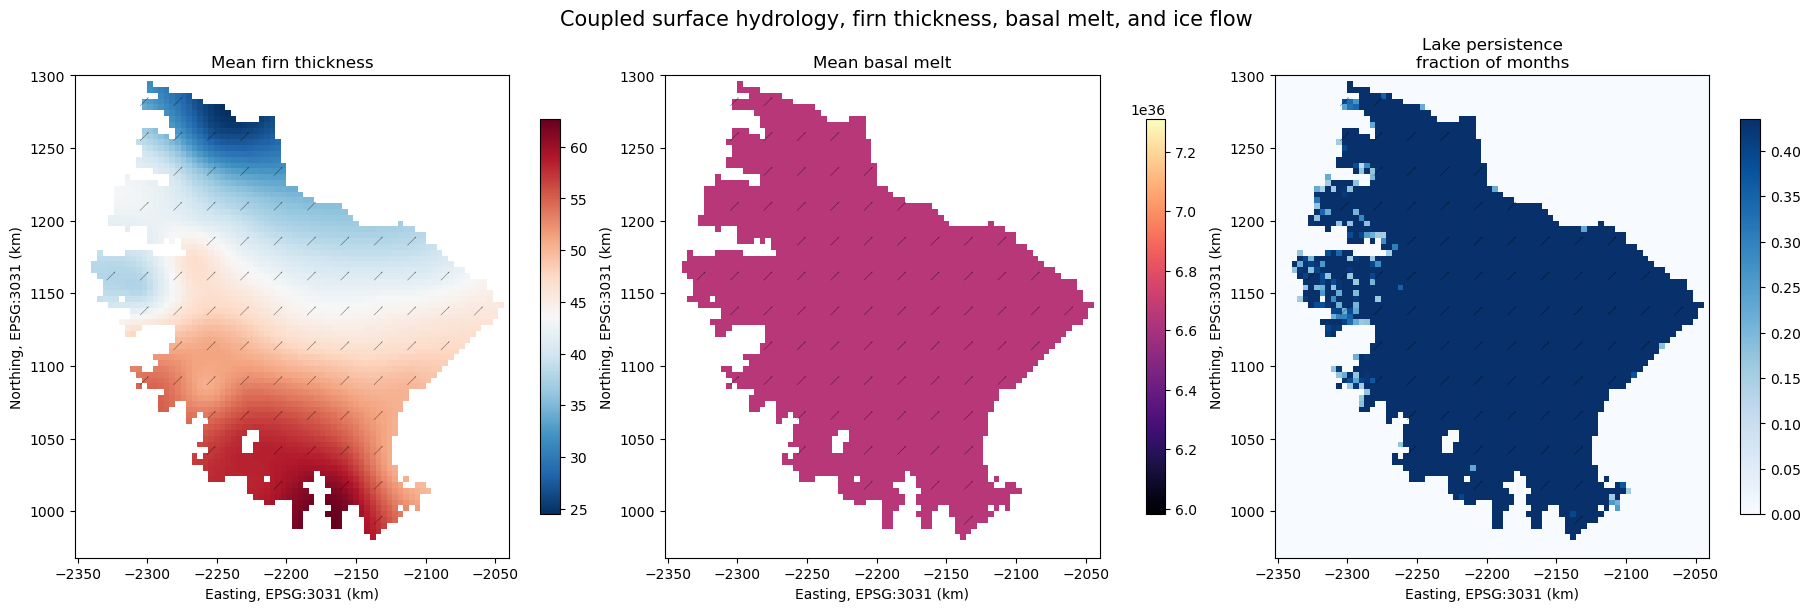

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

panels = [
    (firn_thickness_plot, "Mean firn thickness", "RdBu_r"),
    (melt_plot, "Mean basal melt", "magma"),
    (lake_plot, "Lake persistence\nfraction of months", "Blues"),
]

for ax, (field, title, cmap) in zip(axes, panels):
    im = ax.pcolormesh(x, y, field.T, shading="auto", cmap=cmap)
    ax.quiver(
        x[::qstep], y[::qstep],
        u_plot.values[::qstep, ::qstep].T,
        v_plot.values[::qstep, ::qstep].T,
        color="k",
        scale=qscale,
        width=0.0012,
        headwidth=3,
        headlength=4,
        headaxislength=3.5,
        pivot="mid",
        alpha=0.55
    )
    ax.set_title(title)
    ax.set_xlabel("Easting, EPSG:3031 (km)")
    ax.set_ylabel("Northing, EPSG:3031 (km)")
    fig.colorbar(im, ax=ax, shrink=0.82)

fig.suptitle("Coupled surface hydrology, firn thickness, basal melt, and ice flow", fontsize=15)
plt.show()